In [241]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import gropt
from helper_utils import *
import gropt
from gropt_diffusion import *
from trap_diffusion3 import *
import pypulseq as pp

# Demo on How Stimulation Thresholds Configuration

In [242]:
main_path = '../Sequence_Code/'
timing_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls.mat'
waveform_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls_waveforms.mat'
dt = 1e-5 #200e-6


TE_demo = 50.1e-3

In [243]:
# -------------------------------------------------------- 
# Helper Functions
# -------------------------------------------------------- 

def make_tt_target(wave_dict, dt=1e-5):
    """
    Build a local time grid for a waveform block.
    Safely computes max time across non-empty arrays.
    """

    t_arrays = [
        wave_dict["t_x"],
        wave_dict["t_y"],
        wave_dict["t_z"],
        wave_dict["t_rf"],
    ]

    # Filter out empty arrays
    t_arrays = [t for t in t_arrays if t.size > 0]

    if len(t_arrays) == 0:
        raise ValueError("All waveform time arrays are empty — cannot build tt_target.")

    tmax = max(t.max() for t in t_arrays)

    return np.arange(0, tmax + dt, dt)

def interp_grad(t, g, tt_target):
    """Linear interpolation to target time grid"""
    f = interp1d(t, g, kind='linear', fill_value=0, bounds_error=False)
    return f(tt_target)

def extract_waveforms(wave_data):
    """Extract (t_x, gx), (t_y, gy), (t_z, gz), (t_rf, rf)."""

    t_x, gx = wave_data[0,0][0,:], wave_data[0,0][1,:]
    t_y, gy = wave_data[0,1][0,:], wave_data[0,1][1,:]
    t_z, gz = wave_data[0,2][0,:], wave_data[0,2][1,:]
    t_rf, rf = wave_data[0,-1][0,:], wave_data[0,-1][1,:]

    gx = pp.convert.convert(gx, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
    gy = pp.convert.convert(gy, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
    gz = pp.convert.convert(gz, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
    # if RF not empty, normalize to max abs value
    if rf.size > 0:
        rf = abs(rf) / np.max(abs(rf))

    return {
        "t_x": t_x, "gx": gx,
        "t_y": t_y, "gy": gy,
        "t_z": t_z, "gz": gz,
        "t_rf": t_rf, "rf": rf
    }

def interpolate_waveforms(wave_dict, tt_target):
    """Interpolate gx, gy, gz, rf onto tt_target safely."""

    def safe_interp(t, g):
        if t.size == 0 or g.size == 0:
            return np.zeros_like(tt_target)
        return interp_grad(t, g, tt_target)

    return {
        "gx": safe_interp(wave_dict["t_x"],  wave_dict["gx"]),
        "gy": safe_interp(wave_dict["t_y"],  wave_dict["gy"]),
        "gz": safe_interp(wave_dict["t_z"],  wave_dict["gz"]),
        "rf": safe_interp(wave_dict["t_rf"], wave_dict["rf"]),
        "t":  tt_target
    }
def truncate_rf_dict(rf_dict, i_start=None, i_end=None):
    """
    Return a new rf dictionary truncated between [i_start : i_end],
    including gradients (gx, gy, gz) and RF. Time is 't'.
    """
    t  = rf_dict["t"]
    rf = rf_dict["rf"]
    gx = rf_dict["gx"]
    gy = rf_dict["gy"]
    gz = rf_dict["gz"]

    # Handle None values
    if i_start is None:
        i_start = 0
    if i_end is None:
        i_end = len(t)

    return {
        "t":  t[i_start:i_end] - t[i_start],  # reset time to 0
        "rf": rf[i_start:i_end],
        "gx": gx[i_start:i_end],
        "gy": gy[i_start:i_end],
        "gz": gz[i_start:i_end]
    }

def time_to_index(t_array, t_center_sec):
    """
    Convert a time (in seconds) to the nearest index in t_array.
    """
    return int(np.argmin(np.abs(t_array - t_center_sec)))

In [244]:
# Load ASC file and make SAFE params

# All Asc file locations 
asc_file_name = ['/Users/ariel/Desktop/MP_GradSys_P034_X60.asc',
              '/Users/ariel/Documents/PhD/Projects/asc_files/MP_GradSys_K2309_2250V_951A_XQ_GC04XQ.asc',
              '/Users/ariel/Downloads/MP_GPA_K2309_2250V_793A_GC99 (1).asc']

idx_asc = 0

[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[idx_asc])
print(safe_params)


{'tau1': array([0.0008, 0.0008, 0.0008]), 'tau2': array([0.012, 0.012, 0.012]), 'tau3': array([0.000212, 0.000194, 0.000184]), 'a1': array([0.297, 0.213, 0.275]), 'a2': array([0.5, 0.5, 0.5]), 'a3': array([0.203, 0.287, 0.225]), 'stim_limit': array([34.725, 23.202, 31.168]), 'g_scale': array([0.3324, 0.3369, 0.3059])}


In [245]:
# load .mat file
import os

timings_file = os.path.join(main_path, timing_file_name)
timings_data = loadmat(timings_file)
T_90 = timings_data['rf_90_duration'][0][0] - timings_data['rf_90_rfCenterInclDelay'][0][0] + timings_data['nav_dur'][0][0]
T_180 = timings_data['rf_180_duration'][0][0] 
rf_180_rfCenterInclDelay_demo = timings_data['rf_180_rfCenterInclDelay'][0][0]
sys = timings_data['sys']
T_readout_demo = timings_data['timeToTE'][0][0]

mat_data = loadmat(os.path.join(main_path, waveform_file_name))

In [246]:
mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'tfp_excitation', 'tfp_refocusing', 'wave_data_epi', 'wave_data_fatsat', 'wave_data_rf180', 'wave_data_rf90'])

In [247]:
# --------------------------------------------------------
# Load from mat file
# --------------------------------------------------------
tfp_excitation = mat_data['tfp_excitation']
tfp_refocusing = mat_data['tfp_refocusing']

wave_data_RF90  = mat_data['wave_data_rf90']
wave_data_RF180 = mat_data['wave_data_rf180']
wave_data_EPI   = mat_data['wave_data_epi']

# --------------------------------------------------------
# Extract both RF blocks with one line each
# --------------------------------------------------------
RF90  = extract_waveforms(wave_data_RF90)
RF180 = extract_waveforms(wave_data_RF180)
EPI = extract_waveforms(wave_data_EPI)


# Create target time arrays
rf90_dur  = timings_data['rf_90_duration'][0][0]
rf180_dur = timings_data['rf_180_duration'][0][0]

tt_RF90  = np.arange(0, rf90_dur + dt, dt)
tt_RF180 = np.arange(0, rf180_dur + dt, dt)

tt_EPI    = make_tt_target(EPI,   dt=1e-5)

RF90_interp  = interpolate_waveforms(RF90, tt_RF90)
RF180_interp = interpolate_waveforms(RF180, tt_RF180)
EPI_interp    = interpolate_waveforms(EPI,   tt_EPI)



In [248]:
# Extract center + delay times from timings_data
center_delay_90  = timings_data['rf_90_rfCenterInclDelay'][0][0]
center_delay_180 = timings_data['rf_180_rfCenterInclDelay'][0][0]

# Convert to indices
i_center_delay_90  = time_to_index(RF90_interp["t"], center_delay_90)
i_center_delay_180 = time_to_index(RF180_interp["t"], center_delay_180)

i_center_90  = time_to_index(RF90["t_rf"],  i_center_delay_90)
i_center_180 = time_to_index(RF180["t_rf"], i_center_delay_180)


print(RF90_interp.keys())
# RF90 truncated: from center+delay to end
RF90_truncated = truncate_rf_dict(RF90_interp, i_start=i_center_delay_90)

# RF180 pre: from start to center+delay (include center sample)
RF180_pre  = truncate_rf_dict(RF180_interp, i_end=i_center_delay_180+1)

# RF180 post: from center+delay to end
RF180_post = truncate_rf_dict(RF180_interp, i_start=i_center_delay_180)

dict_keys(['gx', 'gy', 'gz', 'rf', 't'])


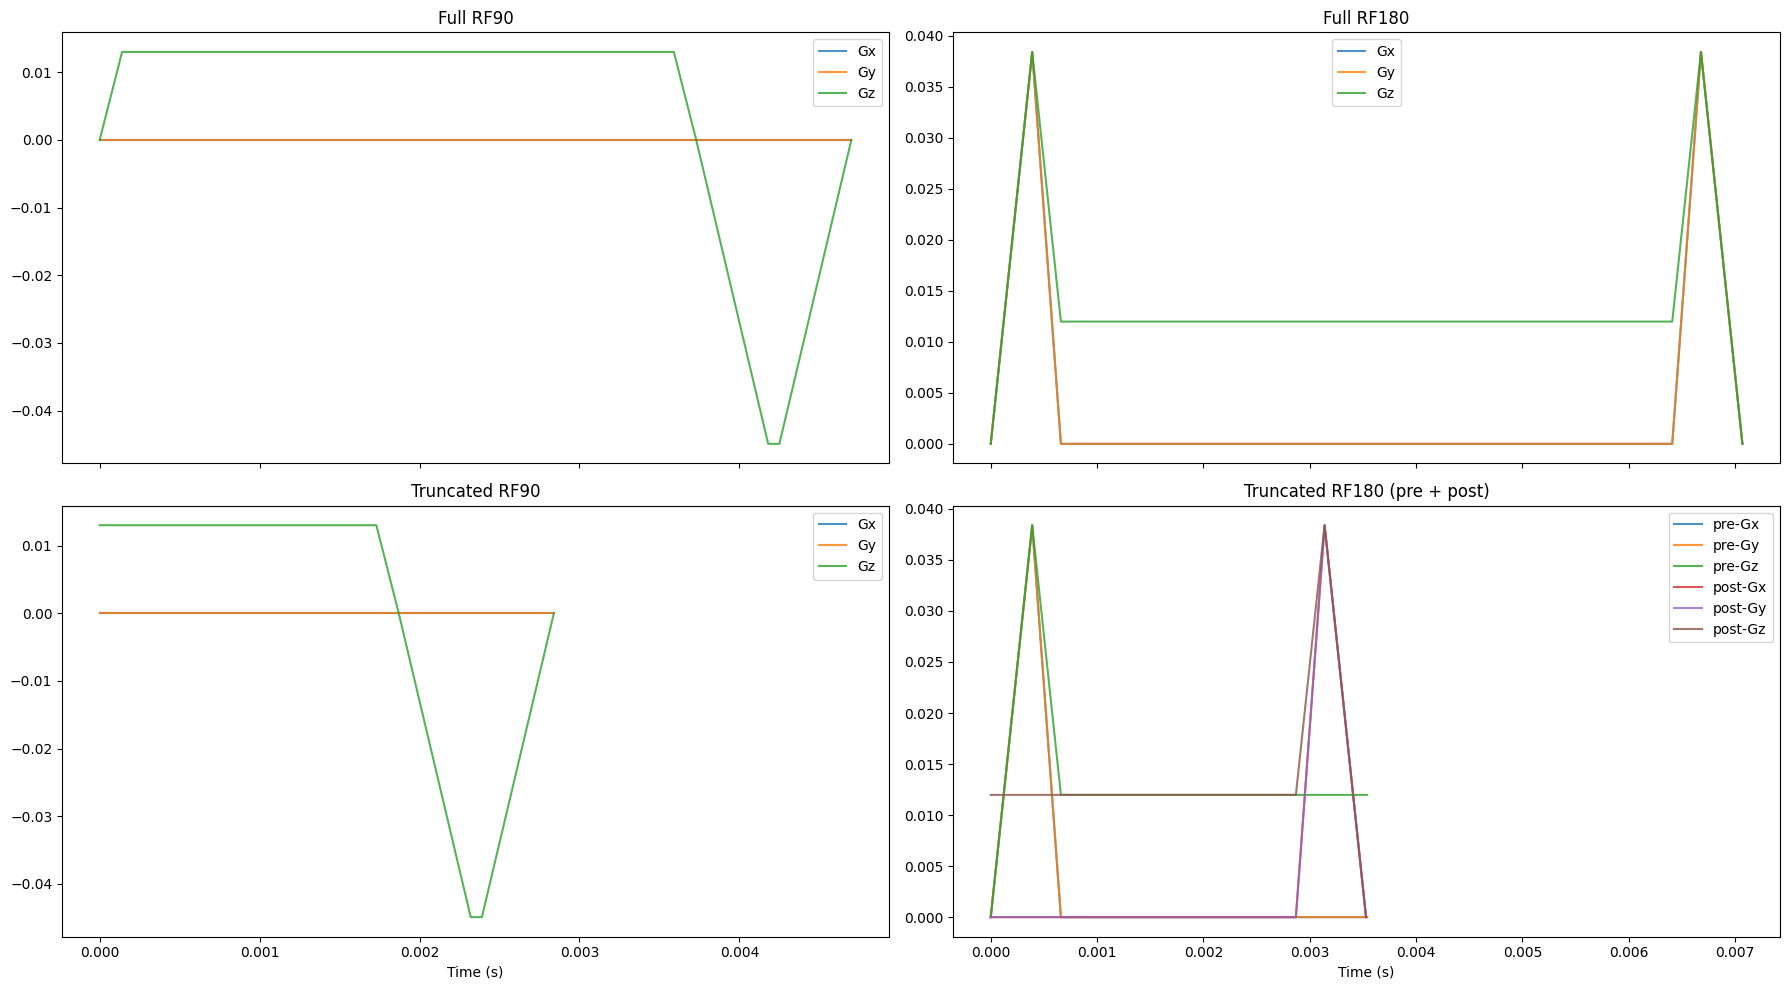

In [249]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10),sharex = 'col')

# ========== Helper: plot block (rf + gradients) ==========
def plot_block(ax, block, label_prefix=""):
    #ax.plot(block['t'], block['rf'], label=f'{label_prefix}RF', lw=2)
    ax.plot(block['t'],  block['gx'], label=f'{label_prefix}Gx', alpha=0.8)
    ax.plot(block['t'],  block['gy'], label=f'{label_prefix}Gy', alpha=0.8)
    ax.plot(block['t'],  block['gz'], label=f'{label_prefix}Gz', alpha=0.8)

# =========================================================
# Row 1, Col 1 : Full RF90
# =========================================================
ax = axs[0, 0]
plot_block(ax, RF90_interp)
ax.set_title("Full RF90")
ax.legend()

# =========================================================
# Row 1, Col 2 : Full RF180
# =========================================================
ax = axs[0, 1]
plot_block(ax, RF180_interp)
ax.set_title("Full RF180")
ax.legend()

# =========================================================
# Row 2, Col 1 : Truncated RF90 (RF + gradients)
# =========================================================
ax = axs[1, 0]
plot_block(ax, RF90_truncated)
ax.set_title("Truncated RF90")
ax.set_xlabel("Time (s)")
ax.legend()

# =========================================================
# Row 2, Col 2 : Truncated RF180 (pre + post, all channels)
# =========================================================
ax = axs[1, 1]

# --- PRE ---
plot_block(ax, RF180_pre, label_prefix="pre-")

# --- POST (shift time so it appears continuous after PRE) ---
shift = 0#RF180_pre["t"][-1] - RF180_post["t"][0] + 1e-9  # tiny offset
RF180_post_shifted = {
    k: (v + shift if k.startswith("t_") else v)
    for k, v in RF180_post.items()
}

plot_block(ax, RF180_post_shifted, label_prefix="post-")

ax.set_title("Truncated RF180 (pre + post)")
ax.set_xlabel("Time (s)")
ax.legend()

# =========================================================
plt.tight_layout()
plt.show()

In [250]:
dur_RF90_full       = RF90_interp['t'][-1] - RF90_interp['t'][0]
dur_RF90_truncated  = RF90_truncated['t'][-1] - RF90_truncated['t'][0]
dur_RF180_pre       = RF180_pre['t'][-1] - RF180_pre['t'][0]
dur_RF180_post      = RF180_post['t'][-1] - RF180_post['t'][0]

print(f"Full RF90 duration:       {dur_RF90_full:.6f} s")
print(f"Truncated RF90 duration:  {dur_RF90_truncated:.6f} s")
print(f"RF180 pre (including center): {dur_RF180_pre:.6f} s")
print(f"RF180 post:               {dur_RF180_post:.6f} s")
print(f"Total RF180 duration:     {dur_RF180_pre + dur_RF180_post:.6f} s")

Full RF90 duration:       0.004700 s
Truncated RF90 duration:  0.002840 s
RF180 pre (including center): 0.003540 s
RF180 post:               0.003530 s
Total RF180 duration:     0.007070 s


/opt/anaconda3/envs/gropt-pulseq/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/gropt-pulseq/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


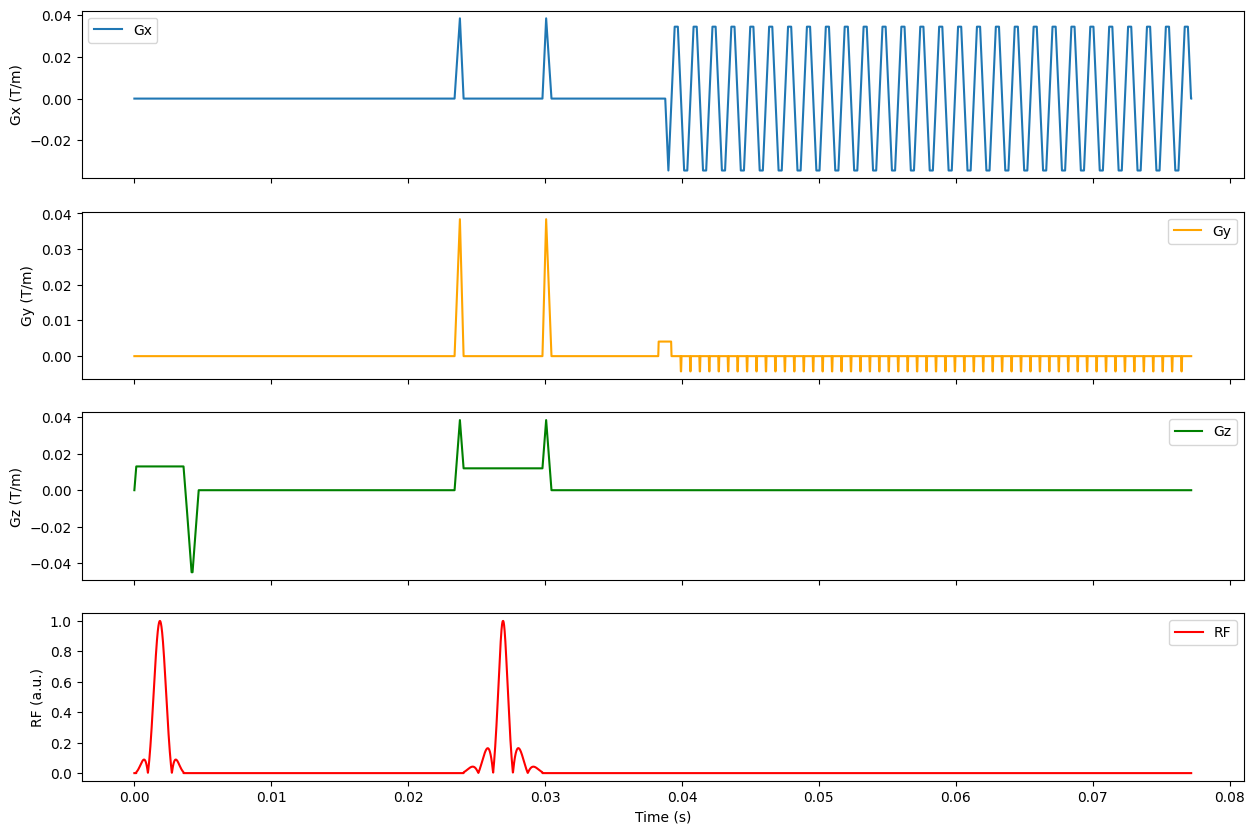

In [251]:
# For a given TE construct a seequnece 
TE  = TE_demo
delayTE1 = np.ceil((TE / 2 - T_90 - rf_180_rfCenterInclDelay_demo) / dt) * dt
delayTE2 = np.ceil((TE / 2 - T_180 + rf_180_rfCenterInclDelay_demo - T_readout_demo) / dt) * dt

# make array of zeros duration of delayTE1 and delayTE2 
zeros_delayTE1 = np.zeros(int(delayTE1 / dt))
zeros_delayTE2 = np.zeros(int(delayTE2 / dt))

# construct base seq in Gx, Gy, Gz, RF
Gx_seq = np.concatenate([RF90_interp['gx'],
                         zeros_delayTE1,
                         RF180_pre['gx'],
                         RF180_post['gx'],
                         zeros_delayTE2,
                         EPI_interp['gx']])
Gy_seq = np.concatenate([RF90_interp['gy'],
                         zeros_delayTE1,
                         RF180_pre['gy'],
                         RF180_post['gy'],
                         zeros_delayTE2,
                         EPI_interp['gy']])
Gz_seq = np.concatenate([RF90_interp['gz'],
                         zeros_delayTE1,
                         RF180_pre['gz'],
                         RF180_post['gz'],     
                            zeros_delayTE2,
                            EPI_interp['gz']])

RF_seq = np.concatenate([RF90_interp['rf'],
                         zeros_delayTE1,
                         RF180_pre['rf'],
                         RF180_post['rf'],
                         zeros_delayTE2,
                         EPI_interp['rf']])

# time array for timepoints over sequence 
time_seq = np.arange(0, len(Gx_seq) * dt, dt)

# Plot the sequence
t_seq = np.arange(0, len(Gx_seq) * dt, dt)
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
ax[0].plot(t_seq, Gx_seq, label='Gx')
ax[0].set_ylabel('Gx (T/m)')
ax[0].legend()
ax[1].plot(t_seq, Gy_seq, label='Gy', color='orange')
ax[1].set_ylabel('Gy (T/m)')
ax[1].legend()
ax[2].plot(t_seq, Gz_seq, label='Gz', color='green')
ax[2].set_ylabel('Gz (T/m)')       
ax[2].legend()
ax[3].plot(t_seq, RF_seq, label='RF', color='red')
ax[3].set_ylabel('RF (a.u.)')
ax[3].set_xlabel('Time (s)')
ax[3].legend() 
plt.show()
# repeat sequence 5 times with a 0 inter-slice TR (repeated excitations)
Gx_seq_full = np.tile(Gx_seq, 5)
Gy_seq_full = np.tile(Gy_seq, 5)
Gz_seq_full = np.tile(Gz_seq, 5)
RF_seq_full = np.tile(RF_seq, 5) 
time_seq_full = np.tile(time_seq, 5)

# Compute PNS/ CNS 
safe_gx = np.array(gropt.gropt_wrapper.get_SAFE(
    Gx_seq_full, dt, safe_params=safe_params, new_first_axis=0))
safe_cardiac_gx = np.array(gropt.gropt_wrapper.get_SAFE(
    Gx_seq_full, dt, safe_params=safe_params_cardiac, new_first_axis=0))

safe_gy = np.array(gropt.gropt_wrapper.get_SAFE(
    Gy_seq_full, dt, safe_params=safe_params, new_first_axis=1))
safe_cardiac_gy = np.array(gropt.gropt_wrapper.get_SAFE(
    Gy_seq_full, dt, safe_params=safe_params_cardiac, new_first_axis=1))

safe_gz = np.array(gropt.gropt_wrapper.get_SAFE(
    Gz_seq_full, dt, safe_params=safe_params, new_first_axis=2))
safe_cardiac_gz = np.array(gropt.gropt_wrapper.get_SAFE(
    Gz_seq_full, dt, safe_params=safe_params_cardiac, new_first_axis=2))

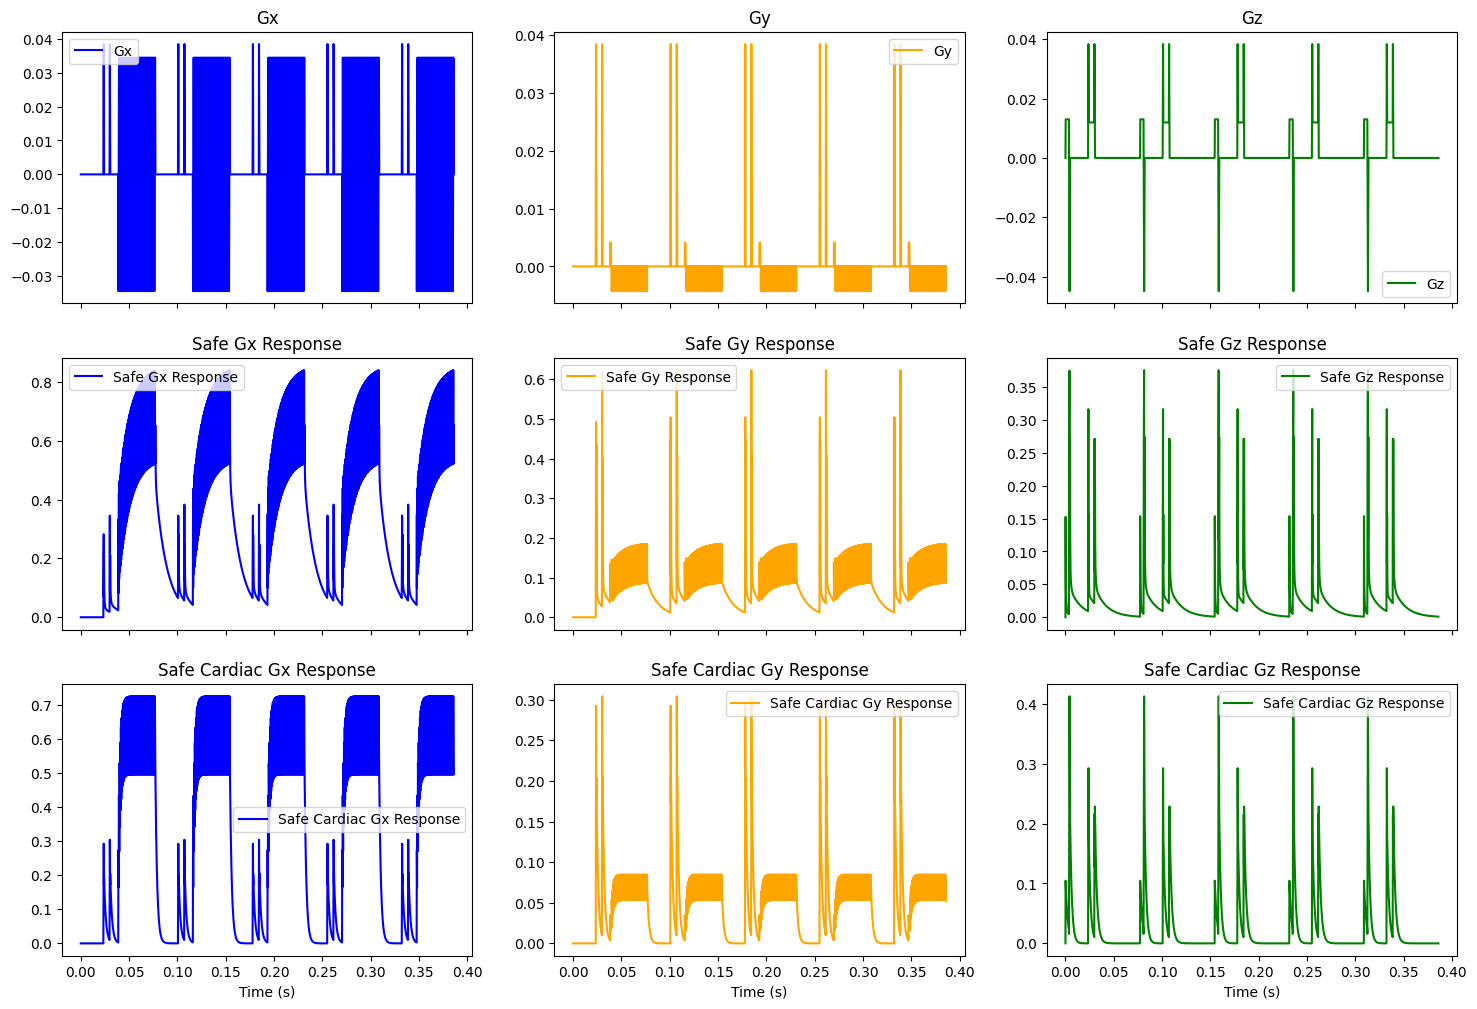

In [252]:
# plot where the columns are Gx , Gy, Gz first row is gradient then next row is Safe reponse then next row is safe cardiac response 
fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
t_plot = np.arange(0, len(Gx_seq_full) * dt, dt)
ax[0,0].plot(t_plot,Gx_seq_full, label='Gx', color='blue')
ax[0,0].set_title('Gx')
ax[0,1].plot(t_plot,Gy_seq_full, label='Gy', color='orange')
ax[0,1].set_title('Gy')
ax[0,2].plot(t_plot,Gz_seq_full, label='Gz', color='green')
ax[0,2].set_title('Gz') 
ax[1,0].plot(t_plot,safe_gx, label='Safe Gx Response', color='blue')
ax[1,0].set_title('Safe Gx Response')
ax[1,1].plot(t_plot,safe_gy, label='Safe Gy Response', color='orange')
ax[1,1].set_title('Safe Gy Response')
ax[1,2].plot(t_plot,safe_gz, label='Safe Gz Response', color='green')
ax[1,2].set_title('Safe Gz Response')
ax[2,0].plot(t_plot,safe_cardiac_gx, label='Safe Cardiac Gx Response', color='blue')
ax[2,0].set_title('Safe Cardiac Gx Response')
ax[2,1].plot(t_plot,safe_cardiac_gy, label='Safe Cardiac Gy Response', color='orange')
ax[2,1].set_title('Safe Cardiac Gy Response')
ax[2,2].plot(t_plot,safe_cardiac_gz, label='Safe Cardiac Gz Response', color='green')
ax[2,2].set_title('Safe Cardiac Gz Response')
for i in range(3):
    for j in range(3):
        ax[i,j].legend()
        if i == 2:
            ax[i,j].set_xlabel('Time (s)')
plt.show()




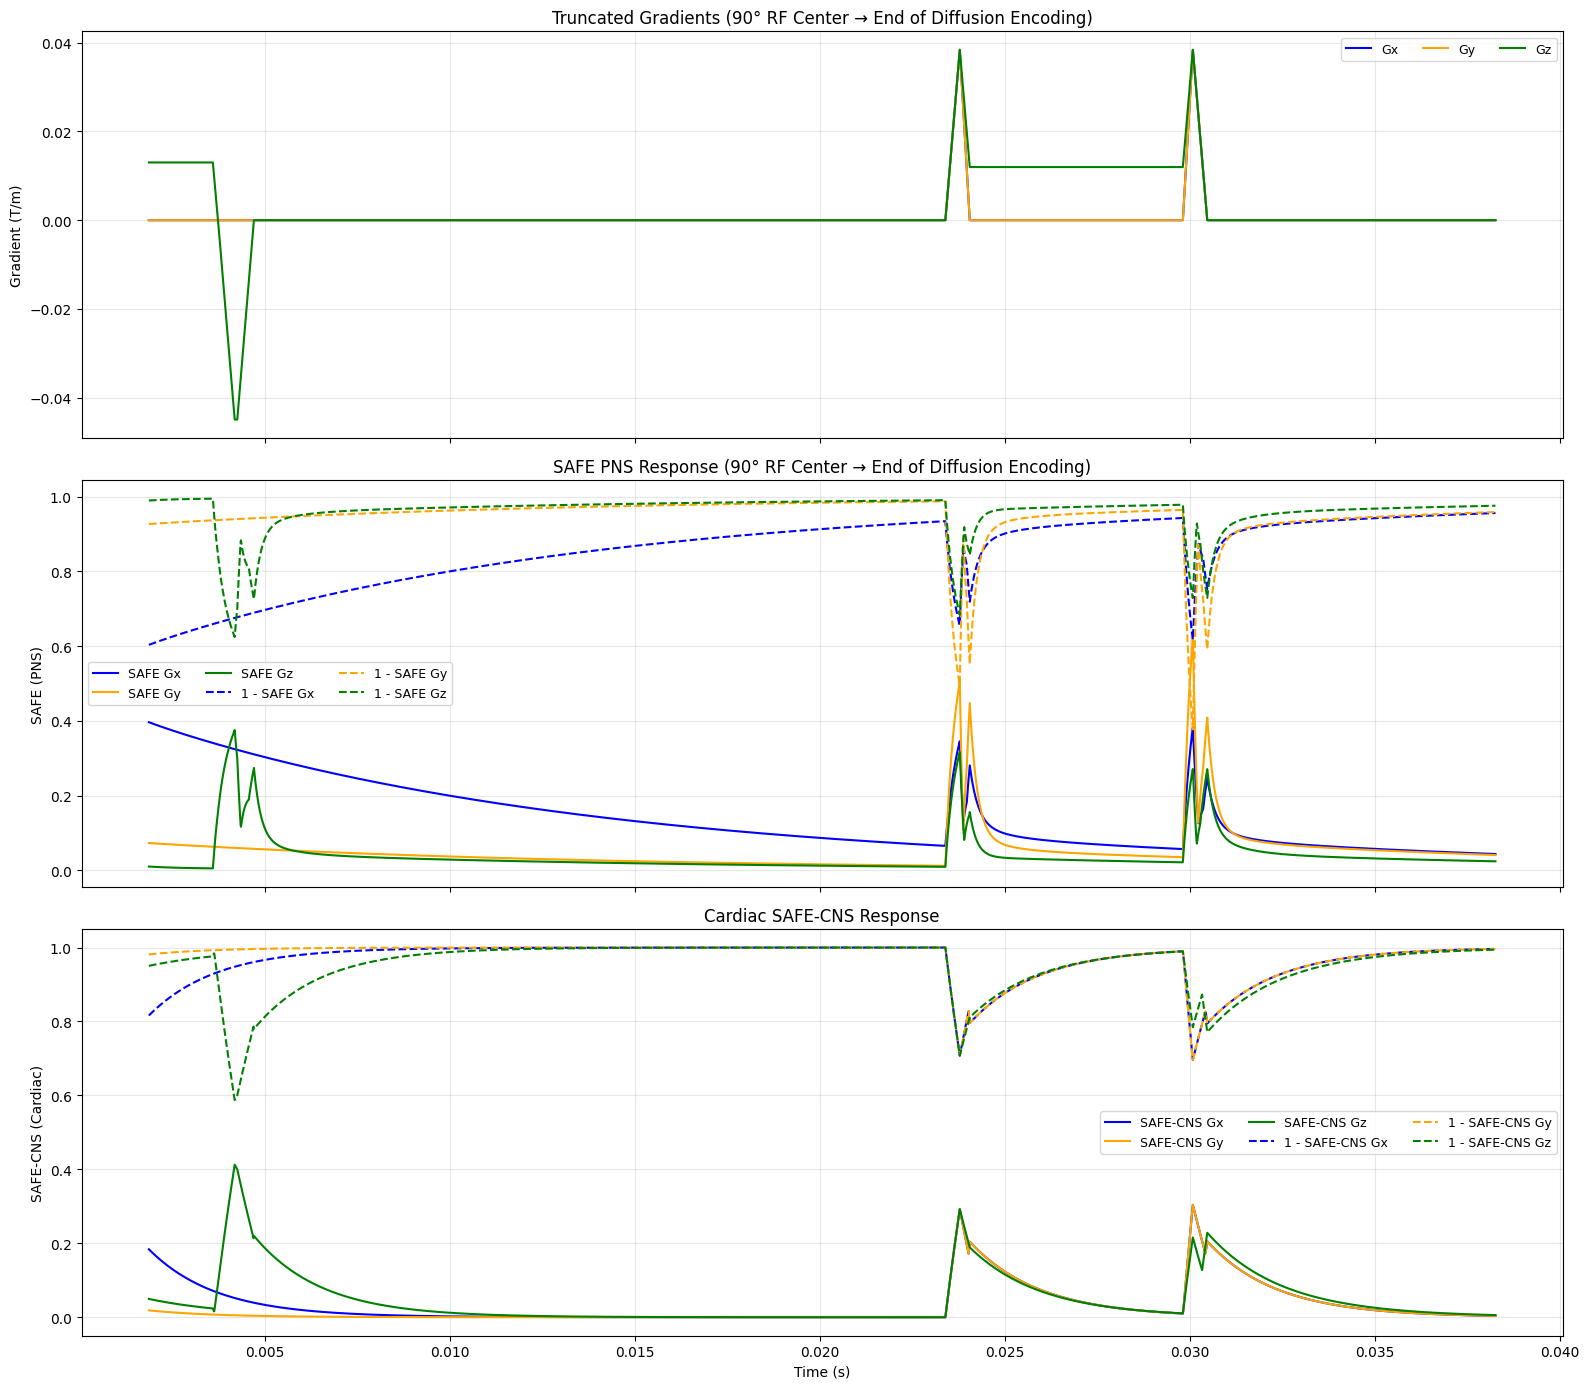

<Figure size 640x480 with 0 Axes>

In [253]:
# Extract the response from the last excitation using time_seq_full 
# --------------------------------------------------------------
# 1. Compute indices inside ONE repeat
# --------------------------------------------------------------

# index of the 90° RF center from your timings_data
idx_center_90 = i_center_delay_90  

# lengths of components inside ONE repeat (before EPI)
len_RF90       = len(RF90_interp['rf'])
len_delayTE1   = len(zeros_delayTE1)
len_RF180_pre  = len(RF180_pre['rf'])
len_RF180_post = len(RF180_post['rf'])
len_delayTE2   = len(zeros_delayTE2)

# end index of the diffusion encoding (end of zeros_delayTE2)
idx_end_TE2 = (
    len_RF90 +
    len_delayTE1 +
    len_RF180_pre +
    len_RF180_post +
    len_delayTE2
)

# --------------------------------------------------------------
# 2. Now compute global indices inside the 5th repeat
# --------------------------------------------------------------

repeat_len = len(Gx_seq)       # length of one full sequence (incl. EPI)
start_5th  = 4 * repeat_len    # 0-based: 5th repeat is repeat index 4

idx_global_center_90 = start_5th + idx_center_90
idx_global_end_TE2   = start_5th + idx_end_TE2


# --------------------------------------------------------------
# 3. Truncate Gradients, RF, Time, and SAFE responses
# --------------------------------------------------------------

Gx_trunc = Gx_seq_full[idx_global_center_90 : idx_global_end_TE2]
Gy_trunc = Gy_seq_full[idx_global_center_90 : idx_global_end_TE2]
Gz_trunc = Gz_seq_full[idx_global_center_90 : idx_global_end_TE2]
RF_trunc = RF_seq_full[idx_global_center_90 : idx_global_end_TE2]

t_trunc  = time_seq_full[idx_global_center_90 : idx_global_end_TE2]

safe_gx_trunc = safe_gx[idx_global_center_90 : idx_global_end_TE2]
safe_gy_trunc = safe_gy[idx_global_center_90 : idx_global_end_TE2]
safe_gz_trunc = safe_gz[idx_global_center_90 : idx_global_end_TE2]

safe_cardiac_gx_trunc = safe_cardiac_gx[idx_global_center_90 : idx_global_end_TE2]
safe_cardiac_gy_trunc = safe_cardiac_gy[idx_global_center_90 : idx_global_end_TE2]
safe_cardiac_gz_trunc = safe_cardiac_gz[idx_global_center_90 : idx_global_end_TE2]

# --------------------------------------------------------------
# 4. (Optional) Plot truncated gradient + SAFE + SAFE-CNS
# --------------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# ============================================================
# ROW 1 — Truncated Gradients (Gx, Gy, Gz)
# ============================================================
ax = axs[0]

ax.plot(t_trunc, Gx_trunc, label='Gx', color='blue')
ax.plot(t_trunc, Gy_trunc, label='Gy', color='orange')
ax.plot(t_trunc, Gz_trunc, label='Gz', color='green')

ax.set_ylabel("Gradient (T/m)")
ax.set_title("Truncated Gradients (90° RF Center → End of Diffusion Encoding)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=9)


# ============================================================
# ROW 2 — SAFE (PNS)
# ============================================================
ax = axs[1]

ax.plot(t_trunc, safe_gx_trunc, label='SAFE Gx', color='blue')
ax.plot(t_trunc, safe_gy_trunc, label='SAFE Gy', color='orange')
ax.plot(t_trunc, safe_gz_trunc, label='SAFE Gz', color='green')

ax.plot(t_trunc, 1 - safe_gx_trunc, '--', label='1 - SAFE Gx', color='blue')
ax.plot(t_trunc, 1 - safe_gy_trunc, '--', label='1 - SAFE Gy', color='orange')
ax.plot(t_trunc, 1 - safe_gz_trunc, '--', label='1 - SAFE Gz', color='green')

ax.set_ylabel("SAFE (PNS)")
ax.set_title("SAFE PNS Response (90° RF Center → End of Diffusion Encoding)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=9)


# ============================================================
# ROW 3 — SAFE-CNS (Cardiac)
# ============================================================
ax = axs[2]

ax.plot(t_trunc, safe_cardiac_gx_trunc, label='SAFE-CNS Gx', color='blue')
ax.plot(t_trunc, safe_cardiac_gy_trunc, label='SAFE-CNS Gy', color='orange')
ax.plot(t_trunc, safe_cardiac_gz_trunc, label='SAFE-CNS Gz', color='green')

ax.plot(t_trunc, 1 - safe_cardiac_gx_trunc, '--', label='1 - SAFE-CNS Gx', color='blue')
ax.plot(t_trunc, 1 - safe_cardiac_gy_trunc, '--', label='1 - SAFE-CNS Gy', color='orange')
ax.plot(t_trunc, 1 - safe_cardiac_gz_trunc, '--', label='1 - SAFE-CNS Gz', color='green')

ax.set_xlabel("Time (s)")
ax.set_ylabel("SAFE-CNS (Cardiac)")
ax.set_title("Cardiac SAFE-CNS Response")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# LAYOUT
# ============================================================
plt.tight_layout()
plt.show()

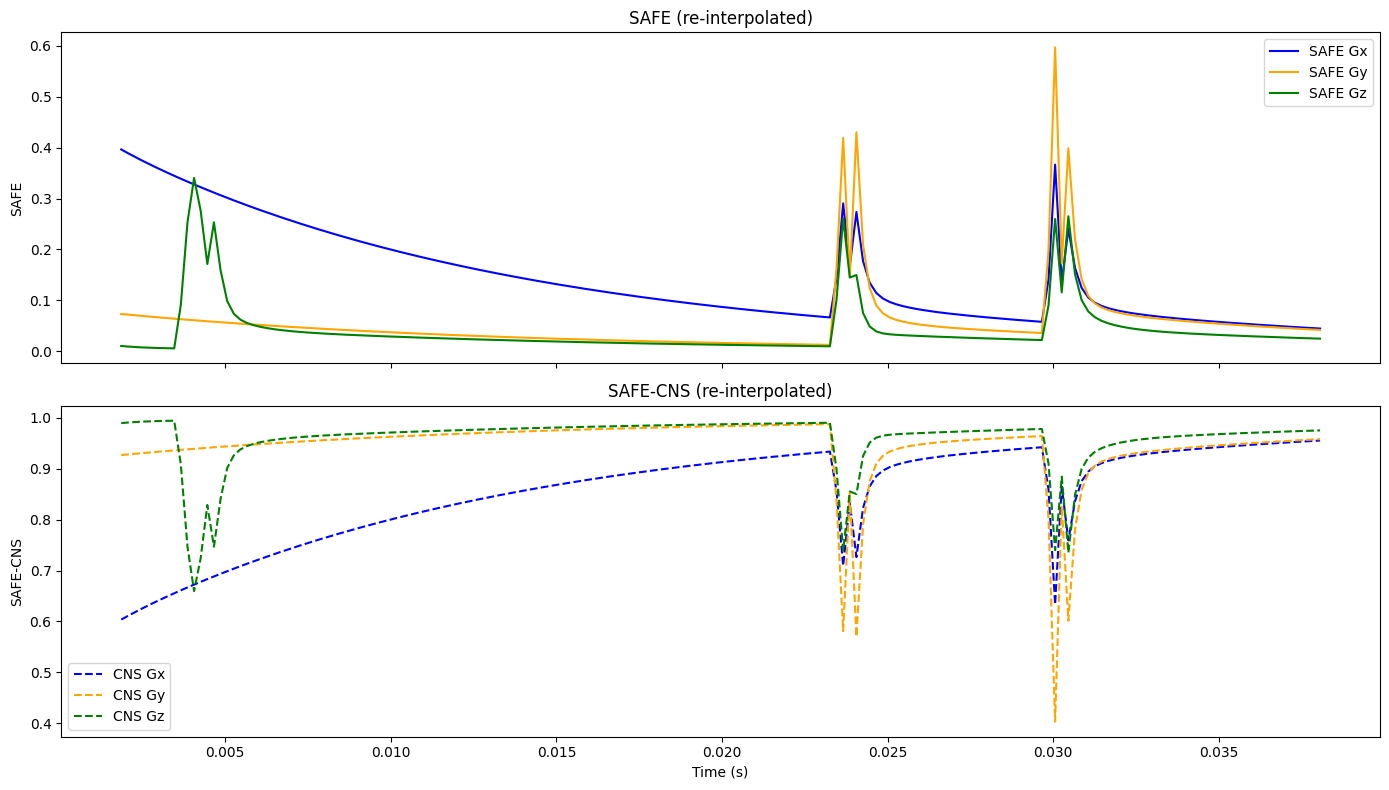

In [254]:
# =========================================================
# OPTIONAL: Re-interpolate SAFE & CNS responses to new raster
# =========================================================

def resample_to_raster(t_old, y_old, raster):
    """
    Resample y_old(t_old) onto a new uniform time axis.
    """
    t_new = np.arange(t_old[0], t_old[-1], raster)
    y_new = np.interp(t_new, t_old, y_old)
    return t_new, y_new

# --------------------------------------------
# Choose your new gradient raster (example)
# --------------------------------------------
new_grad_raster = 200e-6  # 10 microseconds

# --------------------------------------------
# SAFE (original)
# --------------------------------------------
t_new, safe_gx_new = resample_to_raster(t_trunc, safe_gx_trunc, new_grad_raster)
_,      safe_gy_new = resample_to_raster(t_trunc, safe_gy_trunc, new_grad_raster)
_,      safe_gz_new = resample_to_raster(t_trunc, safe_gz_trunc, new_grad_raster)

# --------------------------------------------
# SAFE-CNS (1 - SAFE)
# --------------------------------------------
_, cns_gx_new = resample_to_raster(t_trunc, 1 - safe_gx_trunc, new_grad_raster)
_, cns_gy_new = resample_to_raster(t_trunc, 1 - safe_gy_trunc, new_grad_raster)
_, cns_gz_new = resample_to_raster(t_trunc, 1 - safe_gz_trunc, new_grad_raster)

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# -------------------------
# Row 1: SAFE (interpolated)
# -------------------------
axs[0].plot(t_new, safe_gx_new, label="SAFE Gx", color="blue")
axs[0].plot(t_new, safe_gy_new, label="SAFE Gy", color="orange")
axs[0].plot(t_new, safe_gz_new, label="SAFE Gz", color="green")
axs[0].set_title("SAFE (re-interpolated)")
axs[0].set_ylabel("SAFE")
axs[0].legend()

# -------------------------
# Row 2: CNS (interpolated)
# -------------------------
axs[1].plot(t_new, cns_gx_new, "--", label="CNS Gx", color="blue")
axs[1].plot(t_new, cns_gy_new, "--", label="CNS Gy", color="orange")
axs[1].plot(t_new, cns_gz_new, "--", label="CNS Gz", color="green")
axs[1].set_title("SAFE-CNS (re-interpolated)")
axs[1].set_ylabel("SAFE-CNS")
axs[1].set_xlabel("Time (s)")
axs[1].legend()

plt.tight_layout()
plt.show()

# One Class

In [255]:
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# UTILITY FUNCTIONS
# --------------------------------------------------------------

def interp_lin(t, g, tt):
    """Safe linear interpolation."""
    if t.size == 0 or g.size == 0:
        return np.zeros_like(tt)
    f = interp1d(t, g, kind='linear', fill_value=0, bounds_error=False)
    return f(tt)

def time_to_index(t, t_ref):
    """Nearest index to a reference time."""
    return int(np.argmin(np.abs(t - t_ref)))

def resample_to_raster(t_old, y_old, raster):
    """
    Resample y_old(t_old) onto a new uniform time axis.
    """
    t_new = np.arange(t_old[0], t_old[-1], raster)
    y_new = np.interp(t_new, t_old, y_old)
    return t_new, y_new

# ==============================================================
# MAIN CLASS
# ==============================================================

class PNSCNS_SequenceBuilder:
    """
    Build interpolated waveforms, repeated sequences, compute PNS/CNS responses,
    truncate from 90° RF center to end of zeros_delayTE2, and resample.
    """

    def __init__(self, timing_file, waveform_file,
                 dt_in, dt_out, safe_params, safe_params_cardiac, TE, n_repeats=5):

        self.timing_file  = timing_file
        self.waveform_file = waveform_file
        self.dt_in   = dt_in
        self.dt_out  = dt_out
        self.safe_params = safe_params
        self.safe_params_cardiac = safe_params_cardiac
        self.TE = TE
        self.n_repeats = n_repeats

        # -----------------------------
        # Load data and interpolate
        # -----------------------------
        self._load_timing()
        self._load_waveforms()
        self._interpolate_RF_blocks()
        self._build_diffusion_encoding()
        self._assemble_sequence()
        
        # -----------------------------
        # Repeat sequence and compute SAFE/CNS
        # -----------------------------
        self._repeat_sequence()
        self._compute_safe()

        # -----------------------------
        # Truncate 90° center → end of delayTE2
        # -----------------------------
        self._truncate_center90_to_TE2()

        # -----------------------------
        # Resample SAFE/PNS & CNS
        # -----------------------------
        self._resample_safe_cns()


    # ----------------------------------------------------------
    # Load timing file
    # ----------------------------------------------------------
    def _load_timing(self):
        data = loadmat(self.timing_file)

        self.rf90_dur   = data['rf_90_duration'][0][0]
        self.rf180_dur  = data['rf_180_duration'][0][0]
        self.center90   = data['rf_90_rfCenterInclDelay'][0][0]
        self.center180  = data['rf_180_rfCenterInclDelay'][0][0]
        self.nav_dur    = data['nav_dur'][0][0]
        self.timeToTE   = data['timeToTE'][0][0]
        self.T90        = (self.rf90_dur - self.center90 + self.nav_dur)
        self.T180       = self.rf180_dur
        self.sys = data['sys']  # optional


    # ----------------------------------------------------------
    # Load waveform file
    # ----------------------------------------------------------
    def _load_waveforms(self):
        mat = loadmat(self.waveform_file)
        self.w90  = mat["wave_data_rf90"]
        self.w180 = mat["wave_data_rf180"]
        self.wEPI = mat["wave_data_epi"]


    # ----------------------------------------------------------
    # Extract and interpolate RF/EPI blocks
    # ----------------------------------------------------------
    def _extract(self, W):
        t_x, gx = W[0,0][0,:], W[0,0][1,:]
        t_y, gy = W[0,1][0,:], W[0,1][1,:]
        t_z, gz = W[0,2][0,:], W[0,2][1,:]
        t_rf, rf = W[0,3][0,:], W[0,3][1,:]

        gx = pp.convert.convert(gx, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
        gy = pp.convert.convert(gy, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
        gz = pp.convert.convert(gz, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3

        if rf.size > 0:
            rf = np.abs(rf)/np.max(np.abs(rf))

        return dict(t_x=t_x, gx=gx,
                    t_y=t_y, gy=gy,
                    t_z=t_z, gz=gz,
                    t_rf=t_rf, rf=rf)

    def _interpolate_block(self, block, duration):
        tt = np.arange(0, duration + self.dt_in, self.dt_in)
        gx = interp_lin(block["t_x"], block["gx"], tt)
        gy = interp_lin(block["t_y"], block["gy"], tt)
        gz = interp_lin(block["t_z"], block["gz"], tt)
        rf = interp_lin(block["t_rf"], block["rf"], tt)
        return dict(gx=gx, gy=gy, gz=gz, rf=rf, t=tt)

    def _interpolate_RF_blocks(self):
        self.RF90_raw  = self._extract(self.w90)
        self.RF180_raw = self._extract(self.w180)
        self.EPI_raw   = self._extract(self.wEPI)

        self.RF90_interp  = self._interpolate_block(self.RF90_raw,  self.rf90_dur)
        self.RF180_interp = self._interpolate_block(self.RF180_raw, self.rf180_dur)

        # EPI flexible
        t_arrays = [self.EPI_raw["t_x"], self.EPI_raw["t_y"],
                    self.EPI_raw["t_z"], self.EPI_raw["t_rf"]]
        tmax = max([t.max() for t in t_arrays if t.size>0])
        tt = np.arange(0, tmax + self.dt_in, self.dt_in)
        self.EPI_interp = dict(
            gx=interp_lin(self.EPI_raw["t_x"], self.EPI_raw["gx"], tt),
            gy=interp_lin(self.EPI_raw["t_y"], self.EPI_raw["gy"], tt),
            gz=interp_lin(self.EPI_raw["t_z"], self.EPI_raw["gz"], tt),
            rf=interp_lin(self.EPI_raw["t_rf"], self.EPI_raw["rf"], tt),
            t=tt
        )


    # ----------------------------------------------------------
    # Split RF180 into pre/post, create delays
    # ----------------------------------------------------------
    def _build_diffusion_encoding(self):
        self.i_center_90  = time_to_index(self.RF90_interp["t"],  self.center90)
        self.i_center_180 = time_to_index(self.RF180_interp["t"], self.center180)

        R = self.RF180_interp
        self.RF180_pre = {k:R[k][:self.i_center_180+1] for k in ["gx","gy","gz","rf"]}
        self.RF180_post = {k:R[k][self.i_center_180:]   for k in ["gx","gy","gz","rf"]}

        dt = self.dt_in
        delayTE1 = np.ceil((self.TE/2 - self.T90 - self.center180)/dt)*dt
        delayTE2 = np.ceil((self.TE/2 - self.T180 + self.center180 - self.timeToTE)/dt)*dt

        self.z1 = np.zeros(int(delayTE1/dt))
        self.z2 = np.zeros(int(delayTE2/dt))


    # ----------------------------------------------------------
    # Assemble sequence (one repetition)
    # ----------------------------------------------------------
    def _assemble_sequence(self):
        def cat(keys): return np.concatenate(keys)
        self.Gx_seq = cat([self.RF90_interp["gx"], self.z1,
                           self.RF180_pre["gx"], self.RF180_post["gx"], self.z2,
                           self.EPI_interp["gx"]])
        self.Gy_seq = cat([self.RF90_interp["gy"], self.z1,
                           self.RF180_pre["gy"], self.RF180_post["gy"], self.z2,
                           self.EPI_interp["gy"]])
        self.Gz_seq = cat([self.RF90_interp["gz"], self.z1,
                           self.RF180_pre["gz"], self.RF180_post["gz"], self.z2,
                           self.EPI_interp["gz"]])
        self.RF_seq = cat([self.RF90_interp["rf"], self.z1,
                           self.RF180_pre["rf"], self.RF180_post["rf"], self.z2,
                           self.EPI_interp["rf"]])
        n = len(self.Gx_seq)
        self.t_seq = np.arange(0, n*self.dt_in, self.dt_in)


    # ----------------------------------------------------------
    # Repeat sequence and store full repeated arrays
    # ----------------------------------------------------------
    def _repeat_sequence(self):
        n = self.n_repeats
        self.Gx_seq_full = np.tile(self.Gx_seq, n)
        self.Gy_seq_full = np.tile(self.Gy_seq, n)
        self.Gz_seq_full = np.tile(self.Gz_seq, n)
        self.RF_seq_full = np.tile(self.RF_seq, n)
        self.t_seq_full  = np.tile(self.t_seq, n)


    # ----------------------------------------------------------
    # Compute SAFE / CNS using gropt wrapper
    # ----------------------------------------------------------
    def _compute_safe(self):
        # You need to import your gropt wrapper
        import gropt.gropt_wrapper as gw

        dt = self.dt_in
        self.safe_gx = np.array(gw.get_SAFE(self.Gx_seq_full, dt, safe_params=self.safe_params, new_first_axis=0))
        self.safe_gy = np.array(gw.get_SAFE(self.Gy_seq_full, dt, safe_params=self.safe_params, new_first_axis=1))
        self.safe_gz = np.array(gw.get_SAFE(self.Gz_seq_full, dt, safe_params=self.safe_params, new_first_axis=2))

        self.safe_cardiac_gx = np.array(gw.get_SAFE(self.Gx_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=0))
        self.safe_cardiac_gy = np.array(gw.get_SAFE(self.Gy_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=1))
        self.safe_cardiac_gz = np.array(gw.get_SAFE(self.Gz_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=2))


    # ----------------------------------------------------------
    # Truncate from RF90 center → end of zeros_delayTE2
    # ----------------------------------------------------------
    def _truncate_center90_to_TE2(self):
        len_RF90  = len(self.RF90_interp["rf"])
        len_z1    = len(self.z1)
        len_pre   = len(self.RF180_pre["rf"])
        len_post  = len(self.RF180_post["rf"])
        len_z2    = len(self.z2)
        idx_end_TE2 = len_RF90 + len_z1 + len_pre + len_post + len_z2
        start = self.i_center_90
        end   = idx_end_TE2

        self.Gx_trunc = self.Gx_seq_full[start:end]
        self.Gy_trunc = self.Gy_seq_full[start:end]
        self.Gz_trunc = self.Gz_seq_full[start:end]
        self.t_trunc  = self.t_seq_full[start:end] - self.t_seq_full[start]

        self.safe_gx_trunc = self.safe_gx[start:end]
        self.safe_gy_trunc = self.safe_gy[start:end]
        self.safe_gz_trunc = self.safe_gz[start:end]

        self.safe_cardiac_gx_trunc = self.safe_cardiac_gx[start:end]
        self.safe_cardiac_gy_trunc = self.safe_cardiac_gy[start:end]
        self.safe_cardiac_gz_trunc = self.safe_cardiac_gz[start:end]


    # ----------------------------------------------------------
    # Resample truncated SAFE/PNS & CNS responses to dt_out
    # ----------------------------------------------------------
    def _resample_safe_cns(self):
        dt_out = self.dt_out
        t_old = self.t_trunc

        self.t_out, self.Gx_out = resample_to_raster(t_old, self.Gx_trunc, dt_out)
        _, self.Gy_out = resample_to_raster(t_old, self.Gy_trunc, dt_out)
        _, self.Gz_out = resample_to_raster(t_old, self.Gz_trunc, dt_out)

        _, self.safe_gx_out = resample_to_raster(t_old, self.safe_gx_trunc, dt_out)
        _, self.safe_gy_out = resample_to_raster(t_old, self.safe_gy_trunc, dt_out)
        _, self.safe_gz_out = resample_to_raster(t_old, self.safe_gz_trunc, dt_out)

        _, self.safe_cardiac_gx_out = resample_to_raster(t_old, self.safe_cardiac_gx_trunc, dt_out)
        _, self.safe_cardiac_gy_out = resample_to_raster(t_old, self.safe_cardiac_gy_trunc, dt_out)
        _, self.safe_cardiac_gz_out = resample_to_raster(t_old, self.safe_cardiac_gz_trunc, dt_out)


    # ----------------------------------------------------------
    # Optional plotting function
    # ----------------------------------------------------------
    def plot_all(self):
        fig, axs = plt.subplots(3,1,figsize=(16,12), sharex=True)

        # -----------------------------
        # Top: Gradients
        # -----------------------------
        axs[0].plot(self.t_trunc, self.Gx_trunc, label='Gx')
        axs[0].plot(self.t_trunc, self.Gy_trunc, label='Gy')
        axs[0].plot(self.t_trunc, self.Gz_trunc, label='Gz')
        axs[0].set_ylabel('Gradient (T/m)')
        axs[0].set_title('Truncated Gradients')
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)

        # -----------------------------
        # Middle: SAFE/PNS
        # -----------------------------
        axs[1].plot(self.t_trunc, self.safe_gx_trunc, label='SAFE Gx', color='blue')
        axs[1].plot(self.t_trunc, self.safe_gy_trunc, label='SAFE Gy', color='orange')
        axs[1].plot(self.t_trunc, self.safe_gz_trunc, label='SAFE Gz', color='green')
        axs[1].plot(self.t_trunc, 1 - self.safe_gx_trunc, '--', color='blue', label='1 - SAFE Gx')
        axs[1].plot(self.t_trunc, 1 - self.safe_gy_trunc, '--', color='orange', label='1 - SAFE Gy')
        axs[1].plot(self.t_trunc, 1 - self.safe_gz_trunc, '--', color='green', label='1 - SAFE Gz')
        axs[1].set_ylabel('SAFE (PNS)')
        axs[1].set_title('SAFE (PNS) Response')
        axs[1].legend(ncol=3, fontsize=9)
        axs[1].grid(True, alpha=0.3)

        # -----------------------------
        # Bottom: SAFE-CNS
        # -----------------------------
        axs[2].plot(self.t_trunc, self.safe_cardiac_gx_trunc, label='SAFE-CNS Gx', color='blue')
        axs[2].plot(self.t_trunc, self.safe_cardiac_gy_trunc, label='SAFE-CNS Gy', color='orange')
        axs[2].plot(self.t_trunc, self.safe_cardiac_gz_trunc, label='SAFE-CNS Gz', color='green')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gx_trunc, '--', color='blue', label='1 - SAFE-CNS Gx')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gy_trunc, '--', color='orange', label='1 - SAFE-CNS Gy')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gz_trunc, '--', color='green', label='1 - SAFE-CNS Gz')
        axs[2].set_xlabel('Time (s)')
        axs[2].set_ylabel('SAFE-CNS')
        axs[2].set_title('Cardiac SAFE-CNS Response')
        axs[2].legend(ncol=3, fontsize=9)
        axs[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

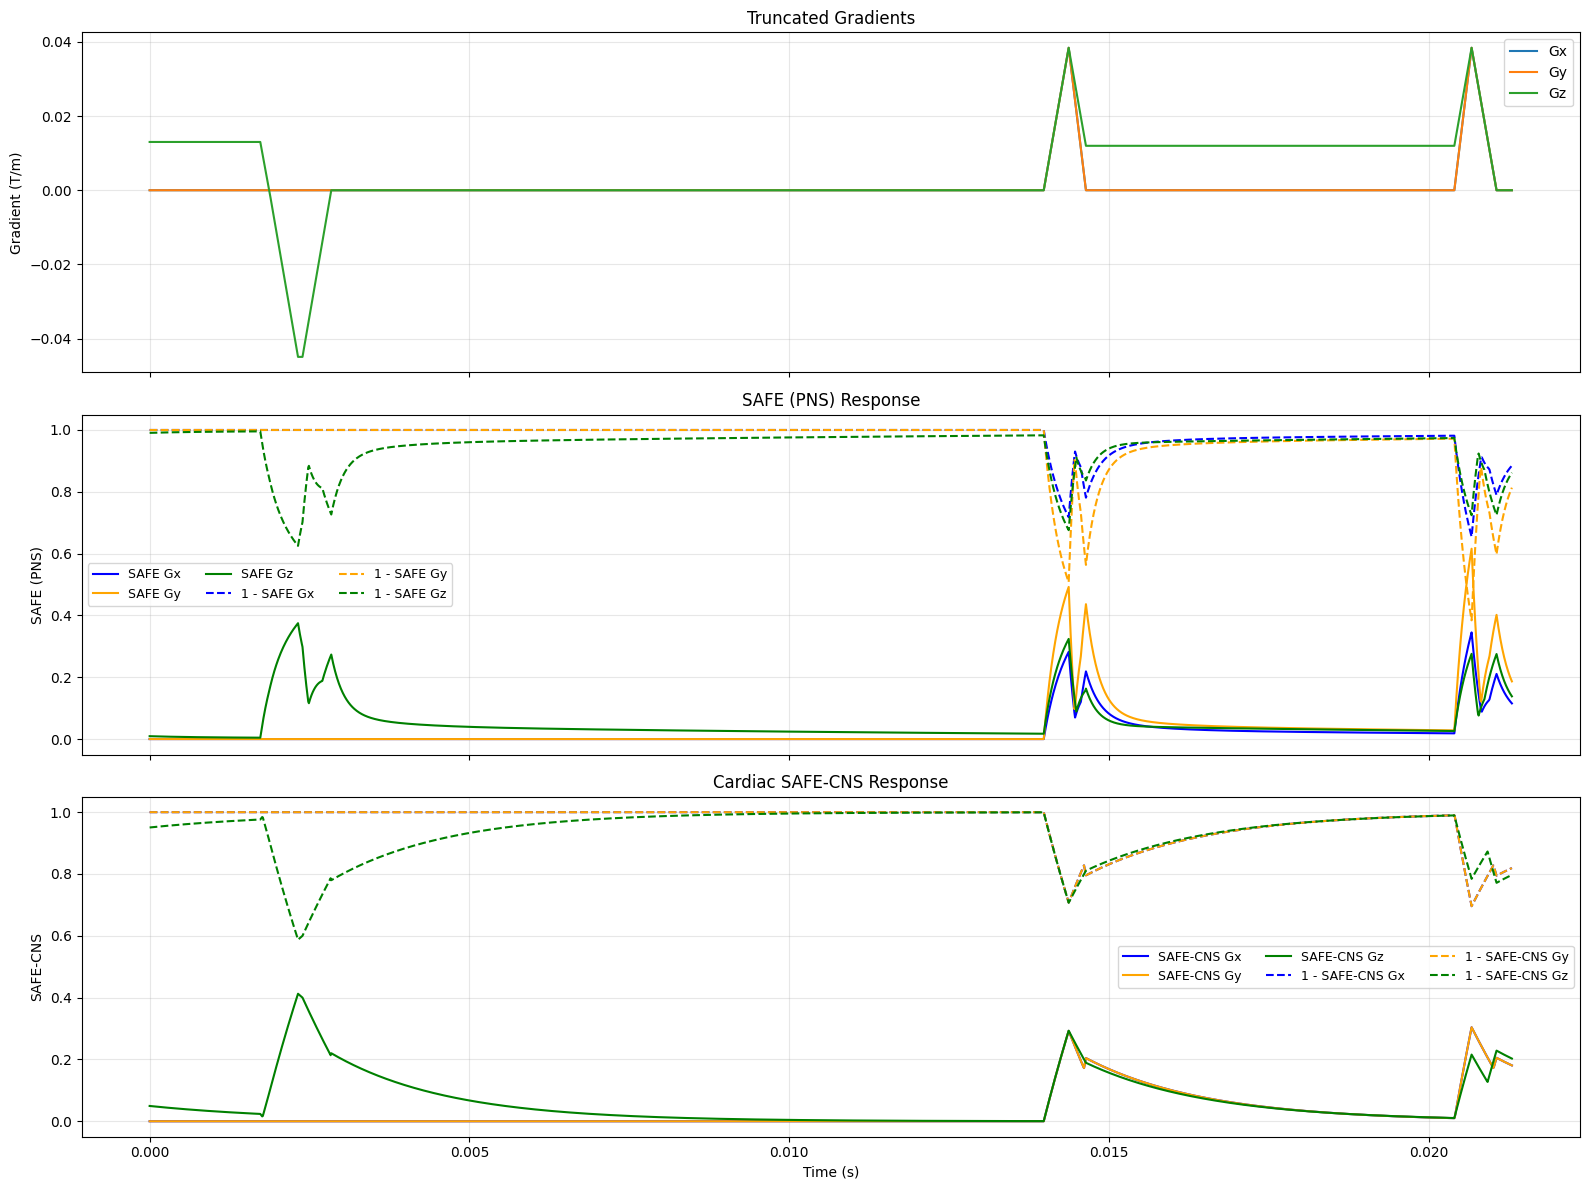

In [260]:

main_path = '../Sequence_Code/'
timing_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls.mat'
waveform_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls_waveforms.mat'

seq = PNSCNS_SequenceBuilder(
    timing_file=os.path.join(main_path, timing_file_name),
    waveform_file=os.path.join(main_path, waveform_file_name),
    dt_in=1e-5,
    dt_out=1e-5,
    safe_params=safe_params,
    safe_params_cardiac=safe_params_cardiac,
    TE=0.035,
    n_repeats=5
)

# Access outputs
Gx_final = seq.Gx_out
safe_final = seq.safe_gx_out
cns_final  = seq.safe_cardiac_gx_out
t_out      = seq.t_out

# Plot
seq.plot_all()

In [ ]:
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# UTILITY FUNCTIONS
# --------------------------------------------------------------

def interp_lin(t, g, tt):
    """Safe linear interpolation."""
    if t.size == 0 or g.size == 0:
        return np.zeros_like(tt)
    f = interp1d(t, g, kind='linear', fill_value=0, bounds_error=False)
    return f(tt)

def time_to_index(t, t_ref):
    """Nearest index to a reference time."""
    return int(np.argmin(np.abs(t - t_ref)))

def resample_to_raster(t_old, y_old, raster):
    """Resample y_old(t_old) onto a new uniform time axis."""
    t_new = np.arange(t_old[0], t_old[-1], raster)
    y_new = np.interp(t_new, t_old, y_old)
    return t_new, y_new

# ==============================================================
# MAIN CLASS
# ==============================================================

class PNSCNS_SequenceBuilder:
    """
    Build interpolated waveforms, repeated sequences, compute PNS/CNS responses,
    truncate from 90° RF center to end of zeros_delayTE2, and resample.
    Includes optional fat-sat block before RF90.
    """

    def __init__(self, timing_file, waveform_file,
                 dt_in, dt_out, safe_params, safe_params_cardiac, TE, n_repeats=5):

        self.timing_file  = timing_file
        self.waveform_file = waveform_file
        self.dt_in   = dt_in
        self.dt_out  = dt_out
        self.safe_params = safe_params
        self.safe_params_cardiac = safe_params_cardiac
        self.TE = TE
        self.n_repeats = n_repeats

        # -----------------------------
        # Load data and interpolate
        # -----------------------------
        self._load_timing()
        self._load_waveforms()
        self._interpolate_RF_blocks()
        self._build_diffusion_encoding()
        self._assemble_sequence()
        
        # -----------------------------
        # Repeat sequence and compute SAFE/CNS
        # -----------------------------
        self._repeat_sequence()
        self._compute_safe()

        # -----------------------------
        # Truncate 90° center → end of zeros_delayTE2
        # -----------------------------
        self._truncate_center90_to_TE2()

        # -----------------------------
        # Resample SAFE/PNS & CNS
        # -----------------------------
        self._resample_safe_cns()


    # ----------------------------------------------------------
    # Load timing file
    # ----------------------------------------------------------
    def _load_timing(self):
        data = loadmat(self.timing_file)

        self.rf90_dur   = data['rf_90_duration'][0][0]
        self.rf180_dur  = data['rf_180_duration'][0][0]
        self.center90   = data['rf_90_rfCenterInclDelay'][0][0]
        self.center180  = data['rf_180_rfCenterInclDelay'][0][0]
        self.nav_dur    = data['nav_dur'][0][0]
        self.timeToTE   = data['timeToTE'][0][0]
        self.T90        = (self.rf90_dur - self.center90 + self.nav_dur)
        self.T180       = self.rf180_dur
        self.sys = data['sys']  # optional


    # ----------------------------------------------------------
    # Load waveform file (including optional fatsat)
    # ----------------------------------------------------------
    def _load_waveforms(self):
        mat = loadmat(self.waveform_file)
        self.w90   = mat["wave_data_rf90"]
        self.w180  = mat["wave_data_rf180"]
        self.wEPI  = mat["wave_data_epi"]
        self.wFAT  = mat.get("wave_data_fatsat", None)  # optional fatsat block


    # ----------------------------------------------------------
    # Extract and interpolate RF/EPI/FAT blocks
    # ----------------------------------------------------------
    def _extract(self, W):
        t_x, gx = W[0,0][0,:], W[0,0][1,:]
        t_y, gy = W[0,1][0,:], W[0,1][1,:]
        t_z, gz = W[0,2][0,:], W[0,2][1,:]
        t_rf, rf = W[0,3][0,:], W[0,3][1,:]

        gx = pp.convert.convert(gx, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
        gy = pp.convert.convert(gy, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
        gz = pp.convert.convert(gz, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3

        if rf.size > 0:
            rf = np.abs(rf)/np.max(np.abs(rf))

        return dict(t_x=t_x, gx=gx,
                    t_y=t_y, gy=gy,
                    t_z=t_z, gz=gz,
                    t_rf=t_rf, rf=rf)

    def _interpolate_block(self, block, duration):
        tt = np.arange(0, duration + self.dt_in, self.dt_in)
        gx = interp_lin(block["t_x"], block["gx"], tt)
        gy = interp_lin(block["t_y"], block["gy"], tt)
        gz = interp_lin(block["t_z"], block["gz"], tt)
        rf = interp_lin(block["t_rf"], block["rf"], tt)
        return dict(gx=gx, gy=gy, gz=gz, rf=rf, t=tt)

    def _interpolate_RF_blocks(self):
        self.RF90_raw  = self._extract(self.w90)
        self.RF180_raw = self._extract(self.w180)
        self.EPI_raw   = self._extract(self.wEPI)

        self.RF90_interp  = self._interpolate_block(self.RF90_raw,  self.rf90_dur)
        self.RF180_interp = self._interpolate_block(self.RF180_raw, self.rf180_dur)

        # Interpolate fatsat if available
        if self.wFAT is not None:
            t_arrays = [self.wFAT[0,0][0,:], self.wFAT[0,1][0,:],
                        self.wFAT[0,2][0,:], self.wFAT[0,3][0,:]]
            dur_fat = max([t.max() for t in t_arrays if t.size>0])
            self.FAT_interp = self._interpolate_block(self._extract(self.wFAT), dur_fat)
        else:
            self.FAT_interp = dict(gx=np.array([]), gy=np.array([]), gz=np.array([]), rf=np.array([]), t=np.array([]))

        # EPI flexible
        t_arrays = [self.EPI_raw["t_x"], self.EPI_raw["t_y"], self.EPI_raw["t_z"], self.EPI_raw["t_rf"]]
        tmax = max([t.max() for t in t_arrays if t.size>0])
        tt = np.arange(0, tmax + self.dt_in, self.dt_in)
        self.EPI_interp = dict(
            gx=interp_lin(self.EPI_raw["t_x"], self.EPI_raw["gx"], tt),
            gy=interp_lin(self.EPI_raw["t_y"], self.EPI_raw["gy"], tt),
            gz=interp_lin(self.EPI_raw["t_z"], self.EPI_raw["gz"], tt),
            rf=interp_lin(self.EPI_raw["t_rf"], self.EPI_raw["rf"], tt),
            t=tt
        )


    # ----------------------------------------------------------
    # Split RF180 into pre/post, create delays
    # ----------------------------------------------------------
    def _build_diffusion_encoding(self):
        self.i_center_90  = time_to_index(self.RF90_interp["t"],  self.center90)
        self.i_center_180 = time_to_index(self.RF180_interp["t"], self.center180)

        R = self.RF180_interp
        self.RF180_pre  = {k:R[k][:self.i_center_180+1] for k in ["gx","gy","gz","rf"]}
        self.RF180_post = {k:R[k][self.i_center_180:]   for k in ["gx","gy","gz","rf"]}

        dt = self.dt_in
        delayTE1 = np.ceil((self.TE/2 - self.T90 - self.center180)/dt)*dt
        delayTE2 = np.ceil((self.TE/2 - self.T180 + self.center180 - self.timeToTE)/dt)*dt

        self.z1 = np.zeros(int(delayTE1/dt))
        self.z2 = np.zeros(int(delayTE2/dt))


    # ----------------------------------------------------------
    # Assemble sequence (one repetition)
    # ----------------------------------------------------------
    # ----------------------------------------------------------
    # Assemble sequence (one repetition)
    # ----------------------------------------------------------
    def _assemble_sequence(self):
        def cat(keys): return np.concatenate(keys)
        self.Gx_seq = cat([
            self.FAT_interp["gx"],    # Fat-sat
            self.RF90_interp["gx"],   # 90° RF
            self.z1,                  # delayTE1
            self.RF180_interp["gx"],  # Full RF180
            self.z2,                  # delayTE2
            self.EPI_interp["gx"]     # EPI readout
        ])
        self.Gy_seq = cat([
            self.FAT_interp["gy"],
            self.RF90_interp["gy"],
            self.z1,
            self.RF180_interp["gy"],
            self.z2,
            self.EPI_interp["gy"]
        ])
        self.Gz_seq = cat([
            self.FAT_interp["gz"],
            self.RF90_interp["gz"],
            self.z1,
            self.RF180_interp["gz"],
            self.z2,
            self.EPI_interp["gz"]
        ])
        self.RF_seq = cat([
            self.FAT_interp["rf"],
            self.RF90_interp["rf"],
            self.z1,
            self.RF180_interp["rf"],
            self.z2,
            self.EPI_interp["rf"]
        ])
        n = len(self.Gx_seq)
        self.t_seq = np.arange(0, n*self.dt_in, self.dt_in)


    # ----------------------------------------------------------
    # Repeat sequence and store full repeated arrays
    # ----------------------------------------------------------
    def _repeat_sequence(self):
        n = self.n_repeats
        self.Gx_seq_full = np.tile(self.Gx_seq, n)
        self.Gy_seq_full = np.tile(self.Gy_seq, n)
        self.Gz_seq_full = np.tile(self.Gz_seq, n)
        self.RF_seq_full = np.tile(self.RF_seq, n)
        self.t_seq_full  = np.tile(self.t_seq, n)


    # ----------------------------------------------------------
    # Compute SAFE / CNS using gropt wrapper
    # ----------------------------------------------------------
    def _compute_safe(self):
        import gropt.gropt_wrapper as gw

        dt = self.dt_in
        self.safe_gx = np.array(gw.get_SAFE(self.Gx_seq_full, dt, safe_params=self.safe_params, new_first_axis=0))
        self.safe_gy = np.array(gw.get_SAFE(self.Gy_seq_full, dt, safe_params=self.safe_params, new_first_axis=1))
        self.safe_gz = np.array(gw.get_SAFE(self.Gz_seq_full, dt, safe_params=self.safe_params, new_first_axis=2))

        self.safe_cardiac_gx = np.array(gw.get_SAFE(self.Gx_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=0))
        self.safe_cardiac_gy = np.array(gw.get_SAFE(self.Gy_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=1))
        self.safe_cardiac_gz = np.array(gw.get_SAFE(self.Gz_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=2))


    # ----------------------------------------------------------
    # Truncate from RF90 center → end of zeros_delayTE2
    # ----------------------------------------------------------
    # ----------------------------------------------------------
    # Truncate from RF90 center → end of sequence (including EPI)
    # ----------------------------------------------------------
    def _truncate_center90_to_TE2(self):
        # Indices of sequence components
        len_FAT     = len(self.FAT_interp["rf"])
        len_RF90    = len(self.RF90_interp["rf"])
        len_z1      = len(self.z1)
        len_RF180   = len(self.RF180_interp["rf"])
        len_z2      = len(self.z2)
        len_EPI     = len(self.EPI_interp["rf"])

        # Total length up to end of zeros_delayTE2
        idx_end_TE2 = len_FAT + len_RF90 + len_z1 + len_RF180 + len_z2 #+ len_EPI

        # Index of RF90 center relative to full sequence
        start = len_FAT + self.i_center_90
        end   = idx_end_TE2

        # Truncate sequences
        self.Gx_trunc = self.Gx_seq_full[start:end]
        self.Gy_trunc = self.Gy_seq_full[start:end]
        self.Gz_trunc = self.Gz_seq_full[start:end]
        self.RF_trunc = self.RF_seq_full[start:end]

        # Reset time array so 0 = start of RF90
        self.t_trunc  = self.t_seq_full[start:end] - self.t_seq_full[start]

        # Truncate SAFE/PNS & CNS
        self.safe_gx_trunc = self.safe_gx[start:end]
        self.safe_gy_trunc = self.safe_gy[start:end]
        self.safe_gz_trunc = self.safe_gz[start:end]

        self.safe_cardiac_gx_trunc = self.safe_cardiac_gx[start:end]
        self.safe_cardiac_gy_trunc = self.safe_cardiac_gy[start:end]
        self.safe_cardiac_gz_trunc = self.safe_cardiac_gz[start:end]


    # ----------------------------------------------------------
    # Resample truncated SAFE/PNS & CNS responses to dt_out
    # ----------------------------------------------------------
    def _resample_safe_cns(self):
        dt_out = self.dt_out
        t_old = self.t_trunc

        self.t_out, self.Gx_out = resample_to_raster(t_old, self.Gx_trunc, dt_out)
        _, self.Gy_out = resample_to_raster(t_old, self.Gy_trunc, dt_out)
        _, self.Gz_out = resample_to_raster(t_old, self.Gz_trunc, dt_out)

        _, self.safe_gx_out = resample_to_raster(t_old, self.safe_gx_trunc, dt_out)
        _, self.safe_gy_out = resample_to_raster(t_old, self.safe_gy_trunc, dt_out)
        _, self.safe_gz_out = resample_to_raster(t_old, self.safe_gz_trunc, dt_out)

        _, self.safe_cardiac_gx_out = resample_to_raster(t_old, self.safe_cardiac_gx_trunc, dt_out)
        _, self.safe_cardiac_gy_out = resample_to_raster(t_old, self.safe_cardiac_gy_trunc, dt_out)
        _, self.safe_cardiac_gz_out = resample_to_raster(t_old, self.safe_cardiac_gz_trunc, dt_out)


    # ----------------------------------------------------------
    # Optional plotting function
    # ----------------------------------------------------------
    def plot_all(self):
        fig, axs = plt.subplots(3,1,figsize=(16,12), sharex=True)

        # -----------------------------
        # Top: Gradients
        # -----------------------------
        axs[0].plot(self.t_trunc, self.Gx_trunc, label='Gx')
        axs[0].plot(self.t_trunc, self.Gy_trunc, label='Gy')
        axs[0].plot(self.t_trunc, self.Gz_trunc, label='Gz')
        axs[0].set_ylabel('Gradient (T/m)')
        axs[0].set_title('Truncated Gradients')
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)

        # -----------------------------
        # Middle: SAFE/PNS
        # -----------------------------
        axs[1].plot(self.t_trunc, self.safe_gx_trunc, label='SAFE Gx', color='blue')
        axs[1].plot(self.t_trunc, self.safe_gy_trunc, label='SAFE Gy', color='orange')
        axs[1].plot(self.t_trunc, self.safe_gz_trunc, label='SAFE Gz', color='green')
        axs[1].plot(self.t_trunc, 1 - self.safe_gx_trunc, '--', color='blue', label='1 - SAFE Gx')
        axs[1].plot(self.t_trunc, 1 - self.safe_gy_trunc, '--', color='orange', label='1 - SAFE Gy')
        axs[1].plot(self.t_trunc, 1 - self.safe_gz_trunc, '--', color='green', label='1 - SAFE Gz')
        axs[1].set_ylabel('SAFE (PNS)')
        axs[1].set_title('SAFE (PNS) Response')
        axs[1].legend(ncol=3, fontsize=9)
        axs[1].grid(True, alpha=0.3)

        # -----------------------------
        # Bottom: SAFE-CNS
        # -----------------------------
        axs[2].plot(self.t_trunc, self.safe_cardiac_gx_trunc, label='SAFE-CNS Gx', color='blue')
        axs[2].plot(self.t_trunc, self.safe_cardiac_gy_trunc, label='SAFE-CNS Gy', color='orange')
        axs[2].plot(self.t_trunc, self.safe_cardiac_gz_trunc, label='SAFE-CNS Gz', color='green')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gx_trunc, '--', color='blue', label='1 - SAFE-CNS Gx')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gy_trunc, '--', color='orange', label='1 - SAFE-CNS Gy')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gz_trunc, '--', color='green', label='1 - SAFE-CNS Gz')
        axs[2].set_xlabel('Time (s)')
        axs[2].set_ylabel('SAFE-CNS')
        axs[2].set_title('Cardiac SAFE-CNS Response')
        axs[2].legend(ncol=3, fontsize=9)
        axs[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

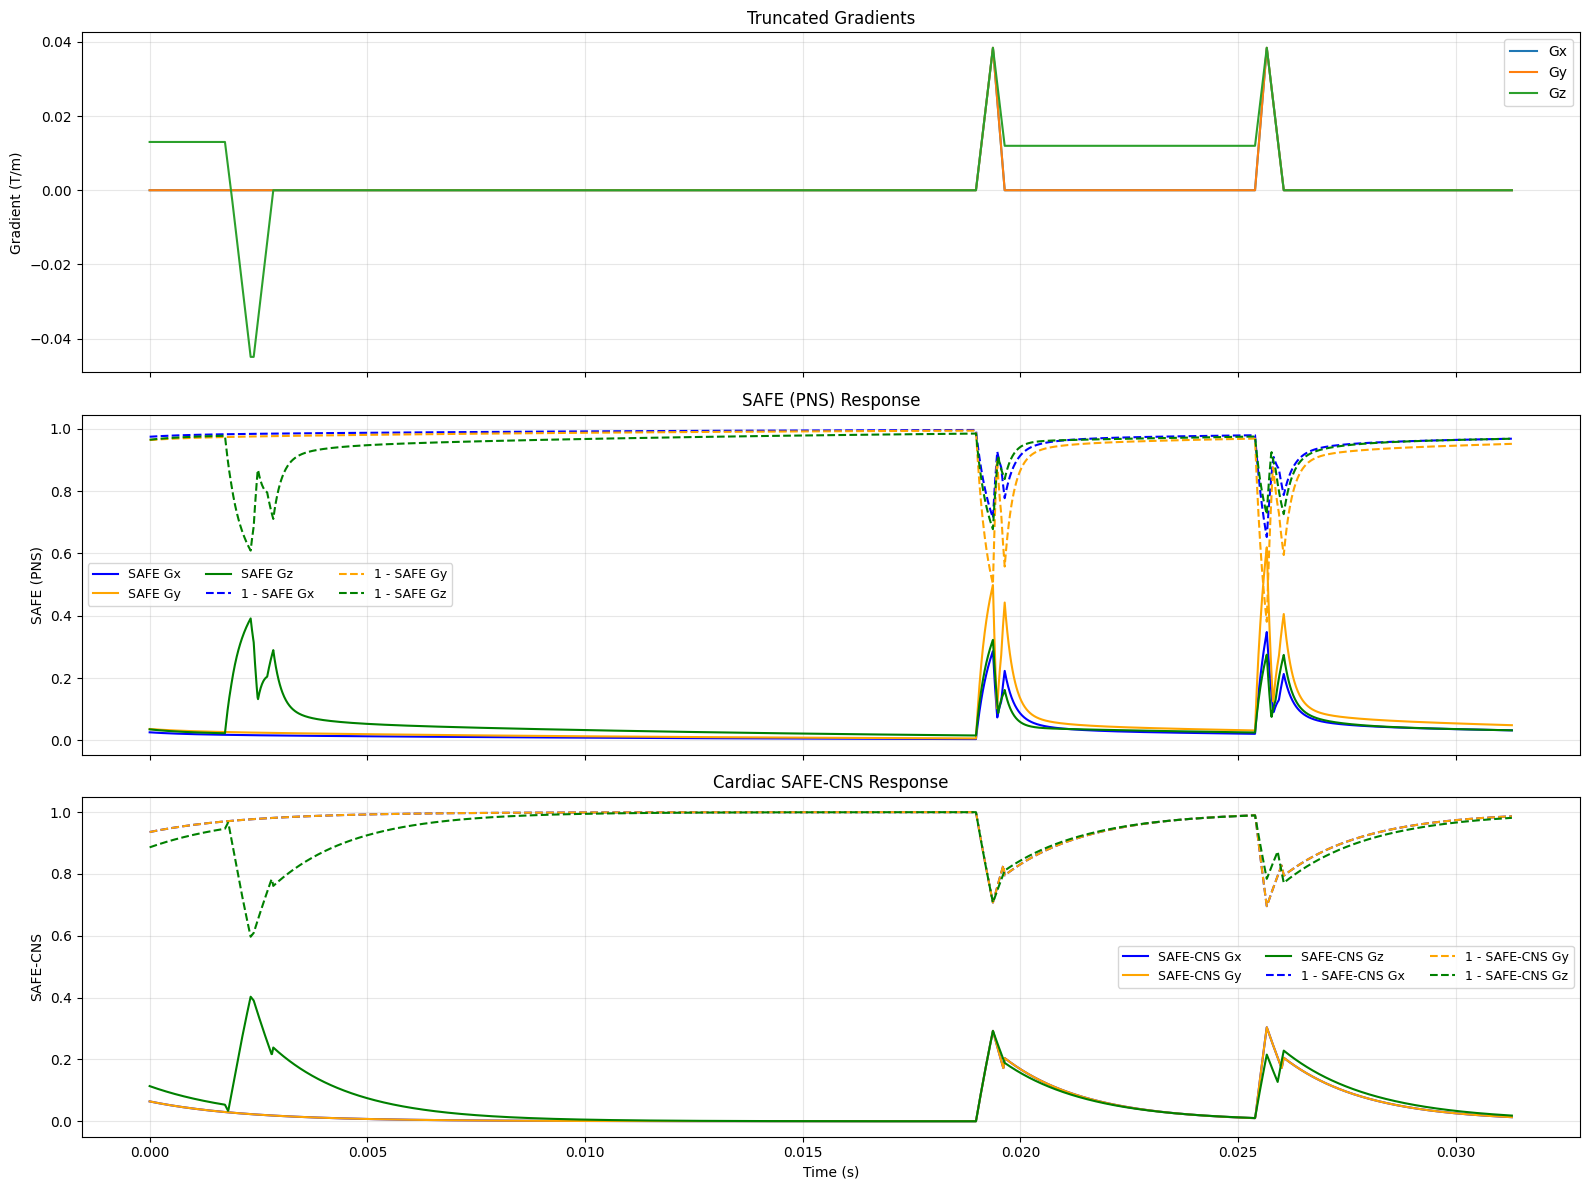

In [ ]:

main_path = '../Sequence_Code/'
timing_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls.mat'
waveform_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls_waveforms.mat'

seq = PNSCNS_SequenceBuilder(
    timing_file=os.path.join(main_path, timing_file_name),
    waveform_file=os.path.join(main_path, waveform_file_name),
    dt_in=1e-5,
    dt_out=200e-6,
    safe_params=safe_params,
    safe_params_cardiac=safe_params_cardiac,
    TE=0.045,
    n_repeats=5
)

# Access outputs
Gx_final = seq.Gx_out
safe_final = seq.safe_gx_out
cns_final  = seq.safe_cardiac_gx_out
t_out      = seq.t_out

# Plot
seq.plot_all()